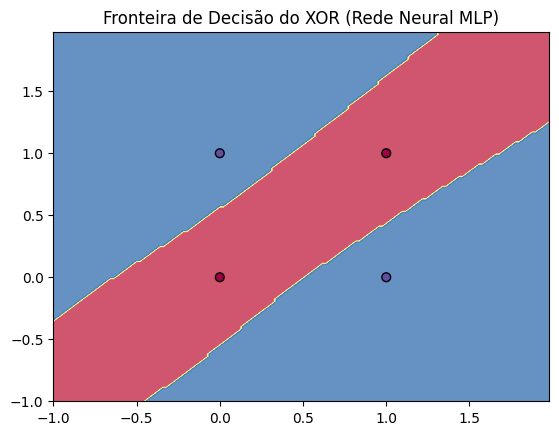

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# A classe MLP representa a nossa Rede Neural
class MLP():
    # 1. INICIALIZAÇÃO
    def __init__(self, input_size=2, hidden_size=4, output_size=1):
        # Aqui definimos a estrutura da rede.
        # input_size = 2 (porque temos duas entradas, ex: 0 e 1)
        # hidden_size = 4 (temos 4 neurônios na camada intermediária/oculta)
        # output_size = 1 (temos uma saída, que será 0 ou 1)

        # Pesos (W) e Viés (b) são a "memória" da rede. Eles começam com valores aleatórios.
        # np.random.randn gera números aleatórios usando a biblioteca Numpy.
        self.W1 = np.random.randn(input_size, hidden_size)
        self.b1 = np.zeros((1, hidden_size))

        self.W2 = np.random.randn(hidden_size, output_size)
        self.b2 = np.zeros((1, output_size))

    # 2. FUNÇÃO DE ATIVAÇÃO
    def sigmoid(self, x):
        # A função sigmoid esmaga qualquer número para que ele fique entre 0 e 1.
        # É assim que o neurônio decide se deve "disparar" um sinal ou não.
        return 1 / (1 + np.exp(-x))

    def sigmoid_derivative(self, x):
        # A derivada é usada na hora do aprendizado para saber o quanto erramos.
        return x * (1 - x)

    # 3. PASSO PARA FRENTE (A TENTATIVA)
    def forward(self, X):
        # A rede recebe os dados e faz multiplicações matemáticas (usando np.dot)
        # para tentar adivinhar a resposta.
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1) # Passa os dados pela primeira camada

        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2) # Passa os dados pela camada final

        return self.a2 # Retorna a adivinhação final da rede

    # 4. TREINAMENTO (O APRENDIZADO)
    def train(self, X, y, epochs=10000, lr=0.1):
        # X são as entradas, y são as respostas certas.
        # epochs é quantas vezes a rede vai estudar os dados (10.000 vezes).
        # lr (learning rate) é a taxa de aprendizado, ou seja, o tamanho do passo que ela dá para corrigir erros.

        X = np.array(X)
        y = np.array(y).reshape(-1, 1) # Organiza os dados no formato correto para o Numpy

        for epoch in range(epochs):
            # Passo 1: Tenta adivinhar (forward)
            output = self.forward(X)

            # Passo 2: Calcula o erro (Resposta certa - adivinhação)
            error = y - output

            # Passo 3: Backpropagation (Aprende com o erro)
            # A rede calcula o quanto cada neurônio contribuiu para o erro e ajusta os pesos (W e b).
            d_output = error * self.sigmoid_derivative(output)
            error_hidden = d_output.dot(self.W2.T)
            d_hidden = error_hidden * self.sigmoid_derivative(self.a1)

            # Atualizando a "memória" da rede
            self.W2 += self.a1.T.dot(d_output) * lr
            self.b2 += np.sum(d_output, axis=0, keepdims=True) * lr
            self.W1 += X.T.dot(d_hidden) * lr
            self.b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

    # 5. PREVISÃO E GRÁFICO (TESTANDO)
    def predict(self, X):
        # Se a resposta for maior que 0.5, consideramos como 1. Se for menor, é 0.
        return (self.forward(X) > 0.5).astype(int)

    def plot_boundary(self, X, y):
        # Esta função usa a biblioteca Matplotlib (plt) para desenhar um gráfico coloridão.
        # Ela mostra visualmente como a rede neural separou os zeros e uns.
        X = np.array(X)
        y = np.array(y)
        h = .02
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        Z = self.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
        plt.scatter(X[:, 0], X[:, 1], c=y, s=40, edgecolors='k', cmap=plt.cm.Spectral)
        plt.title("Fronteira de Decisão do XOR (Rede Neural MLP)")
        plt.show()

# ==========================================
# ÁREA DE EXECUÇÃO (USANDO O CÓDIGO ACIMA)
# ==========================================

# 1. Definimos o problema XOR:
# Se as entradas são iguais, a saída é 0. Se são diferentes, a saída é 1.
entradas = [[0,0], [0,1], [1,0], [1,1]]
saidas = [0, 1, 1, 0]

# 2. Criamos o "Cérebro" (nossa rede neural)
# Ela terá 2 entradas, 4 neurônios intermediários e 1 saída.
rede_neural = MLP(input_size=2, hidden_size=4, output_size=1)

# 3. Colocamos a rede para estudar
# Ela vai olhar para as entradas e saídas 10.000 vezes para aprender o padrão.
rede_neural.train(entradas, saidas, epochs=10000, lr=0.1)

# 4. Geramos o gráfico para ver o resultado do que ela aprendeu
rede_neural.plot_boundary(entradas, saidas)